## Quantize embeddings

In [2]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers.quantization import  quantize_embeddings

/Users/dani/Desktop/Codebase/AI-Agents-with-RAG-LLMs-and-Knowledge-Graphs/.venv-3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/3v/vv10bbld10n93scl1ywy2vgm0000gn/T/ipykernel_10043/161793534.py:4: DeprecationWarning: Importing from 'sentence_transformers.quantization' is deprecated and will be removed in a future version. Please use 'sentence_transformers.util.quantization' instead.
  from sentence_transformers.quantization import  quantize_embeddings


In [3]:
sentences = [
    "I need to go to the bank to deposit some money.",
    "The river bank was flooded after the heavy rain.",
    "She works at a bank downtown.",
    "We set up our picnic by the river bank.",
    "He withdrew cash from the bank yesterday.",
    "There are many fish along the river bank.",
    "The bank offers loans with low interest rates.",
    "Children were playing on the river bank.",
    "I have a meeting at the bank in the morning.",
    "The erosion is affecting the river bank."
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 29080.06it/s]


In [5]:
embeddings = model.encode(sentences)

In [6]:
embeddings

array([[ 0.08260678, -0.00688011, -0.05087187, ...,  0.03948563,
         0.0628718 , -0.07936997],
       [ 0.01375621,  0.02513966,  0.05606842, ..., -0.03233892,
         0.0150784 ,  0.01100208],
       [ 0.03059145, -0.03713192, -0.01234475, ..., -0.00212553,
         0.04012953, -0.05214844],
       ...,
       [ 0.04532351,  0.00346632, -0.01990443, ...,  0.06593809,
         0.02881216,  0.00752143],
       [ 0.01943297,  0.05073689, -0.04757971, ...,  0.00413537,
        -0.0988569 , -0.07054196],
       [ 0.06731775,  0.03313136,  0.06929339, ..., -0.07560297,
         0.08094576, -0.02923866]], shape=(10, 384), dtype=float32)

In [7]:
embeddings.shape

(10, 384)

In [8]:
binary_embeddings = quantize_embeddings(embeddings, precision="binary")

In [9]:
binary_embeddings.shape

(10, 48)

In [10]:
384/8


48.0

In [11]:
binary_embeddings

array([[  18, -126,  120,    4,  -73,  -91,  100,  105,  -48,  -97,  -67,
          18,   31,  120,   67,   74,  110,  -64,   -8,   76,  -82,   55,
         -60,   44,  -95,  121,   28, -119,   50,   90,  -29,  102, -113,
          17,  101,   37, -111,  122,   42, -120,  -17,  -78,   16,  -71,
          28, -126,   14,  -82],
       [ 123, -119, -100,   65,  -68,   95,  -16,   37,   90,  -82,   46,
         111,  -66,  120,  112,  -58,   10, -124, -111,   60,   26,   53,
        -121,  124,   56,   83,  -66,  -69,   58,   83,   67,  -50,  -40,
          45,   76,   22,    8,  -12,   -6,  100, -117,   20,   25,   27,
         -72,  -19,   30,  -85],
       [  22,  -93,   97,    1,   -2, -125,   33,  109, -126,  -65,  -76,
          16,  -65,   50,  -15,   66,   -4,   77,   88,  -68,   50,  -73,
          69,   33,   57,   91,   60,   25,   50,   71,   71,   64,    2,
          42,  -89,   43,  -95,  -37,  -88,   32,  -50, -108,   27, -101,
        -115, -118,   58,  -94],
       [  91,

In [12]:
int8_embeddings = quantize_embeddings(
    embeddings,
    precision="int8",
    calibration_embeddings=embeddings,
)

In [13]:
int8_embeddings

array([[  82,  -61,  -87, ...,   71,  101,  -90],
       [-128,    9,  103, ...,  -52,   33,  126],
       [ -76, -128,  -18, ...,    0,   69,  -25],
       ...,
       [ -31,  -38,  -32, ...,  117,   53,  118],
       [-110,   66,  -81, ...,   10, -128,  -69],
       [  36,   27,  127, ..., -128,  127,   30]],
      shape=(10, 384), dtype=int8)

In [14]:
int8_embeddings.shape

(10, 384)

In [14]:
print(embeddings.nbytes, binary_embeddings.nbytes, int8_embeddings.nbytes)


15360 480 3840


In [15]:
10*384*4

15360

<BarContainer object of 3 artists>

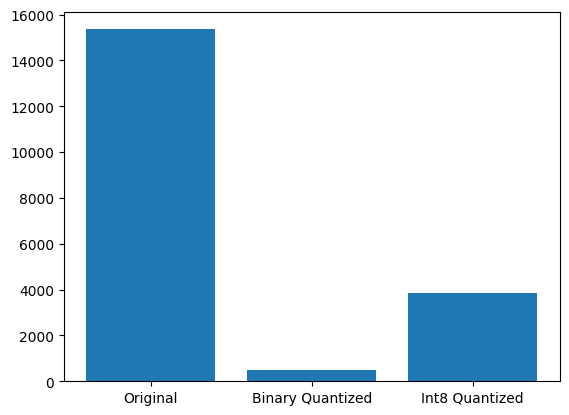

In [15]:
plt.bar(["Original", "Binary Quantized", "Int8 Quantized"], [embeddings.nbytes, binary_embeddings.nbytes, int8_embeddings.nbytes])